# Live coherent-scaling analysis

You can run this notebook **while the simulation script is still running**.

It supports both the previous SQLite database schema (`repeat_results`) and the
latest schema (`point_results`). Only fully committed epsilon points are read;
the point currently being simulated is invisible until it finishes.

By default the notebook uses only **fully completed scaling repeats**. Thus, if
repeat 1 is complete and repeat 2 is only halfway through, the plot uses repeat
1 only and still gives a complete scaling curve.

In [1]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DB_FILE = Path("coherent_phase_gate_scaling.sqlite")

# True: clean live plot using only repeats that contain every paper epsilon.
# False: use every completed epsilon point even when repeat counts differ.
USE_ONLY_COMPLETE_REPEATS = True

PAPER_SCHEDULE = [
    (0.00300, 1001),
    (0.00424, 253),
    (0.00600, 65),
    (0.00849, 17),
    (0.01200, 5),
    (0.01700, 1),
]

FIT_MAX_EPSILON = 0.012

SAVE_FIGURE = True
FIGURE_PATH = Path("fig_coherent_scaling_live.pdf")


In [2]:
if not DB_FILE.exists():
    raise FileNotFoundError(DB_FILE)

def table_names():
    conn = sqlite3.connect(DB_FILE, timeout=60.0)
    conn.execute("PRAGMA busy_timeout = 60000")
    try:
        rows = conn.execute(
            "SELECT name FROM sqlite_master WHERE type='table'"
        ).fetchall()
        return {row[0] for row in rows}
    finally:
        conn.close()

def read_table(table_name):
    conn = sqlite3.connect(DB_FILE, timeout=60.0)
    conn.execute("PRAGMA busy_timeout = 60000")
    try:
        return pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    finally:
        conn.close()

tables = table_names()

# New runner: point_results + run_sessions.
# Previous runner: repeat_results and no persisted timing columns.
if "point_results" in tables:
    DATA_SCHEMA = "latest"
    point_all = read_table("point_results")
    session_df = (
        read_table("run_sessions")
        if "run_sessions" in tables
        else pd.DataFrame()
    )
elif "repeat_results" in tables:
    DATA_SCHEMA = "previous"
    point_all = read_table("repeat_results").copy()
    if "elapsed_seconds" not in point_all.columns:
        point_all["elapsed_seconds"] = np.nan
    if "started_at" not in point_all.columns:
        point_all["started_at"] = pd.NA
    session_df = pd.DataFrame()
else:
    raise RuntimeError(
        "This database contains neither point_results nor repeat_results."
    )

signal_df = read_table("csb_signals")
chunk_df = read_table("csb_chunks")

print("Detected database schema:", DATA_SCHEMA)

# A repeat is complete only when every (epsilon, rep) paper point is present.
expected_keys = {
    (round(float(e), 12), int(r))
    for e, r in PAPER_SCHEDULE
}

progress_rows = []
for repeat_id, sub in point_all.groupby("repeat_id", sort=True):
    present_keys = {
        (round(float(row.epsilon), 12), int(row.rep))
        for row in sub.itertuples()
    }
    elapsed = sub["elapsed_seconds"].to_numpy(float)
    elapsed = elapsed[np.isfinite(elapsed)]
    progress_rows.append({
        "repeat_id": int(repeat_id),
        "completed_epsilon_points": len(present_keys),
        "complete_repeat": present_keys == expected_keys,
        "accumulated_wall_seconds": (
            float(np.sum(elapsed)) if len(elapsed) else np.nan
        ),
    })

progress = pd.DataFrame(progress_rows)
if not progress.empty:
    progress["accumulated_wall_hours"] = (
        progress["accumulated_wall_seconds"] / 3600.0
    )

display(progress)


Detected database schema: latest


,repeat_id,completed_epsilon_points,complete_repeat,accumulated_wall_seconds,accumulated_wall_hours
0,0,6,True,68132.189051,18.925608
1,1,6,True,70933.706838,19.703807
2,2,6,True,74567.396170,20.713166
3,3,6,True,71625.884114,19.896079
4,4,6,True,66728.256621,18.535627
5,5,6,True,66990.120501,18.608367
6,6,6,True,70049.989489,19.458330
7,7,6,True,85066.336670,23.629538
8,8,6,True,66242.742117,18.400762
9,9,6,True,74984.587635,20.829052


In [3]:
complete_repeat_ids = progress.loc[
    progress["complete_repeat"], "repeat_id"
].astype(int).tolist()

if USE_ONLY_COMPLETE_REPEATS:
    if not complete_repeat_ids:
        raise RuntimeError(
            "No full scaling repeat has finished yet. "
            "Set USE_ONLY_COMPLETE_REPEATS=False for a partial live preview."
        )
    point_df = point_all[
        point_all["repeat_id"].isin(complete_repeat_ids)
    ].copy()
    print("Using complete repeat IDs:", complete_repeat_ids)
else:
    point_df = point_all.copy()
    print("Using all committed epsilon points, including partial repeats.")

if point_df.empty:
    raise RuntimeError("No committed scaling data found.")

display(
    point_df[
        [
            "epsilon", "rep", "repeat_id",
            "g_offdiag", "delta_theta", "g_axis",
            "process_infidelity", "elapsed_seconds",
        ]
    ].sort_values(["repeat_id", "epsilon"])
)


Using complete repeat IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


,epsilon,rep,repeat_id,g_offdiag,delta_theta,g_axis,process_infidelity,elapsed_seconds
0,0.00300,1001,0,0.999935,0.000335,1.0,0.000032,51338.745559
1,0.00424,253,0,0.999730,0.000912,1.0,0.000135,12402.962949
2,0.00600,65,0,0.998973,0.002359,1.0,0.000515,3222.139496
3,0.00849,17,0,0.996181,0.005911,1.0,0.001918,854.082938
4,0.01200,5,0,0.986403,0.016118,1.0,0.006862,258.243018
5,0.01700,1,0,0.957476,0.029260,1.0,0.021467,56.015091
6,0.00300,1001,1,0.999932,0.000323,1.0,0.000034,52581.960425
7,0.00424,253,1,0.999706,0.000910,1.0,0.000147,13677.583738
8,0.00600,65,1,0.998933,0.002501,1.0,0.000535,3422.207921
9,0.00849,17,1,0.996286,0.006066,1.0,0.001866,914.216918


In [4]:
summary_rows = []

for (epsilon, rep), sub in point_df.groupby(["epsilon", "rep"], sort=True):
    row = {
        "epsilon": float(epsilon),
        "rep": int(rep),
        "n_repeats": int(sub["repeat_id"].nunique()),
    }

    for metric in [
        "g_offdiag",
        "g_axis",
        "process_fidelity",
        "process_infidelity",
        "average_gate_fidelity",
        "average_gate_infidelity",
    ]:
        values = sub[metric].to_numpy(float)
        values = values[np.isfinite(values)]

        row[f"{metric}_mean"] = (
            np.mean(values) if len(values) else np.nan
        )

        row[f"{metric}_std"] = (
            np.std(values, ddof=1)
            if len(values) > 1
            else np.nan
        )

    # Signed phase error
    delta = sub["delta_theta"].to_numpy(float)
    delta = delta[np.isfinite(delta)]

    row["delta_theta_mean"] = (
        np.mean(delta) if len(delta) else np.nan
    )

    row["delta_theta_std"] = (
        np.std(delta, ddof=1)
        if len(delta) > 1
        else np.nan
    )

    # Keep |delta| as a diagnostic if needed later
    abs_delta = np.abs(delta)

    row["abs_delta_mean"] = (
        np.mean(abs_delta) if len(abs_delta) else np.nan
    )

    row["abs_delta_std"] = (
        np.std(abs_delta, ddof=1)
        if len(abs_delta) > 1
        else np.nan
    )

    row["offdiag_loss_mean"] = 1.0 - row["g_offdiag_mean"]
    row["offdiag_loss_std"] = row["g_offdiag_std"]

    row["axis_loss_mean"] = 1.0 - row["g_axis_mean"]
    row["axis_loss_std"] = row["g_axis_std"]

    summary_rows.append(row)


summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("epsilon")
    .reset_index(drop=True)
)

display(summary_df)

,epsilon,rep,n_repeats,g_offdiag_mean,g_offdiag_std,g_axis_mean,g_axis_std,process_fidelity_mean,process_fidelity_std,process_infidelity_mean,...,average_gate_infidelity_mean,average_gate_infidelity_std,delta_theta_mean,delta_theta_std,abs_delta_mean,abs_delta_std,offdiag_loss_mean,offdiag_loss_std,axis_loss_mean,axis_loss_std
0,0.00300,1001,10,0.999931,0.000003,1.0,0.0,0.999965,0.000002,0.000035,...,0.000023,0.000001,0.000331,0.000004,0.000331,0.000004,0.000069,0.000003,0.0,0.0
1,0.00424,253,10,0.999722,0.000010,1.0,0.0,0.999861,0.000005,0.000139,...,0.000093,0.000003,0.000922,0.000010,0.000922,0.000010,0.000278,0.000010,0.0,0.0
2,0.00600,65,10,0.998934,0.000037,1.0,0.0,0.999465,0.000019,0.000535,...,0.000356,0.000013,0.002472,0.000081,0.002472,0.000081,0.001066,0.000037,0.0,0.0
3,0.00849,17,10,0.996037,0.000163,1.0,0.0,0.998009,0.000082,0.001991,...,0.001327,0.000055,0.006230,0.000374,0.006230,0.000374,0.003963,0.000163,0.0,0.0
4,0.01200,5,10,0.986162,0.000448,1.0,0.0,0.993031,0.000224,0.006969,...,0.004646,0.000149,0.014263,0.001126,0.014263,0.001126,0.013838,0.000448,0.0,0.0
5,0.01700,1,10,0.955722,0.001714,1.0,0.0,0.977674,0.000835,0.022326,...,0.014884,0.000556,0.027601,0.004692,0.027601,0.004692,0.044278,0.001714,0.0,0.0


In [5]:
def fixed_power_fit(x, y, power, fit_max, yerr=None):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    if yerr is None:
        yerr = np.full_like(y, np.nan)
    else:
        yerr = np.asarray(yerr, float)

    mask = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (y > 0)
        & (x <= fit_max * (1 + 1e-12))
    )

    if np.count_nonzero(mask) < 2:
        return {
            "power": int(power),
            "prefactor": np.nan,
            "num_fit_points": int(np.count_nonzero(mask)),
        }

    xf = x[mask]
    yf = y[mask]
    ef = yerr[mask]

    log_a_samples = np.log(yf) - power * np.log(xf)

    relative_error = np.divide(
        ef,
        yf,
        out=np.full_like(yf, np.nan),
        where=yf > 0,
    )

    weights = np.ones_like(yf)
    usable = np.isfinite(relative_error) & (relative_error > 0)
    weights[usable] = 1.0 / relative_error[usable]**2

    log_a = np.sum(weights * log_a_samples) / np.sum(weights)

    return {
        "power": int(power),
        "prefactor": float(np.exp(log_a)),
        "num_fit_points": int(np.count_nonzero(mask)),
    }


x = summary_df["epsilon"].to_numpy(float)

fit_specs = {
    "1-g_off": (
        "offdiag_loss_mean",
        "offdiag_loss_std",
        4,
    ),
    "1-f_axis": (
        "axis_loss_mean",
        "axis_loss_std",
        4,
    ),
    "delta": (
        "delta_theta_mean",
        "delta_theta_std",
        3,
    ),
    "1-F_pro": (
        "process_infidelity_mean",
        "process_infidelity_std",
        4,
    ),
}


fit_results = {}

for name, (mean_col, std_col, power) in fit_specs.items():
    fit_results[name] = fixed_power_fit(
        x=x,
        y=summary_df[mean_col].to_numpy(float),
        power=power,
        fit_max=FIT_MAX_EPSILON,
        yerr=summary_df[std_col].to_numpy(float),
    )


fit_df = pd.DataFrame(
    [
        {
            "quantity": name,
            **result,
        }
        for name, result in fit_results.items()
    ]
)

display(fit_df)

print("fit_results keys =", fit_results.keys())

,quantity,power,prefactor,num_fit_points
0,1-g_off,4,780617.954439,5
1,1-f_axis,4,NaN,0
2,delta,3,12063.784468,5
3,1-F_pro,4,391589.197511,5


fit_results keys = dict_keys(['1-g_off', '1-f_axis', 'delta', '1-F_pro'])


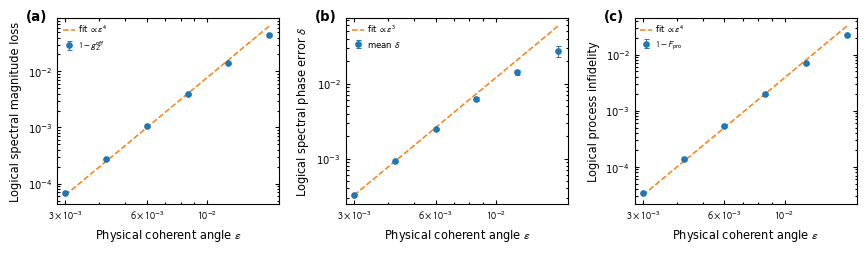

In [6]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter


# ============================================================
# Basic settings
# ============================================================

# x should already be defined in the notebook
x_plot = np.asarray(x, dtype=float)

FIT_MAX_EPSILON = globals().get(
    "FIT_MAX_EPSILON",
    np.sort(x_plot[np.isfinite(x_plot) & (x_plot > 0)])[-2],
)

SAVE_FIGURE = globals().get("SAVE_FIGURE", True)

FIGURE_PATH = globals().get(
    "FIGURE_PATH",
    "coherent_phase_gate_ft_scaling.pdf",
)


# ============================================================
# Fixed-power fit
# ============================================================

def fixed_power_fit(x, y, power, fit_max, yerr=None):
    """
    Fit

        y = A * x^power

    with fixed power.

    Only points with x <= fit_max are used to determine A.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if yerr is None:
        yerr = np.full_like(y, np.nan)
    else:
        yerr = np.asarray(yerr, dtype=float)

    mask = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (y > 0)
        & (x <= fit_max * (1.0 + 1e-12))
    )

    if np.count_nonzero(mask) < 2:
        return {
            "prefactor": np.nan,
            "power": float(power),
            "fit_mask": mask,
        }

    x_fit = x[mask]
    y_fit = y[mask]
    yerr_fit = yerr[mask]

    basis = x_fit ** power

    weights = np.ones_like(y_fit)

    valid_err = (
        np.isfinite(yerr_fit)
        & (yerr_fit > 0)
    )

    weights[valid_err] = (
        1.0 / yerr_fit[valid_err]**2
    )

    prefactor = (
        np.sum(weights * basis * y_fit)
        / np.sum(weights * basis**2)
    )

    return {
        "prefactor": float(prefactor),
        "power": float(power),
        "fit_mask": mask,
    }


# ============================================================
# Error bars for log-y panels
# ============================================================

def safe_log_yerr(y, yerr):
    """
    If the lower error bar crosses zero on a log axis,
    only the plotted lower part is clipped.

    The mean and std values themselves are unchanged.
    """

    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    yerr = np.where(
        np.isfinite(yerr),
        yerr,
        0.0,
    )

    lower = np.minimum(
        yerr,
        0.95 * np.maximum(y, 1e-300),
    )

    return np.vstack([
        lower,
        yerr,
    ])


# ============================================================
# Axis formatting
# ============================================================

def format_axis(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        width=0.8,
    )

    ax.tick_params(
        axis="both",
        which="major",
        length=3.0,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        length=1.8,
    )

    ax.grid(False)


def panel_label(ax, text):
    ax.text(
        -0.14,
        1.045,
        text,
        transform=ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        ha="left",
        va="top",
    )


def set_coherent_xticks(ax):
    """
    Keep clean major ticks while retaining the final
    epsilon point near 1.7e-2.
    """

    ax.set_xticks([
        3e-3,
        6e-3,
        1e-2,
    ])

    ax.set_xticklabels([
        r"$3\times10^{-3}$",
        r"$6\times10^{-3}$",
        r"$10^{-2}$",
    ])

    ax.set_xlim(
        2.8e-3,
        1.85e-2,
    )

    ax.xaxis.set_minor_formatter(
        NullFormatter()
    )


# ============================================================
# Draw fixed-power fit over full data range
# ============================================================

def plot_fit_full_range(
    ax,
    x_all,
    fit,
    label,
    color=None,
):
    """
    Determine the fit only from the low-epsilon points,
    but draw the fitted power law through the full x range.
    """

    if not np.isfinite(fit["prefactor"]):
        return

    x_all = np.asarray(
        x_all,
        dtype=float,
    )

    valid = (
        np.isfinite(x_all)
        & (x_all > 0)
    )

    if np.count_nonzero(valid) < 2:
        return

    x_dense = np.logspace(
        np.log10(np.min(x_all[valid])),
        np.log10(np.max(x_all[valid])),
        300,
    )

    ax.plot(
        x_dense,
        fit["prefactor"]
        * x_dense**fit["power"],
        linestyle="--",
        linewidth=1.1,
        color=color,
        label=label,
        zorder=1,
    )


# ============================================================
# Data
# ============================================================

# ------------------------------------------------------------
# (a) Spectral magnitude loss
# ------------------------------------------------------------

offdiag_mean = summary_df[
    "offdiag_loss_mean"
].to_numpy(dtype=float)

offdiag_std = summary_df[
    "offdiag_loss_std"
].to_numpy(dtype=float)


# ------------------------------------------------------------
# (b) Signed delta_theta
#
# point_df contains the independent complete-workflow repeats.
# Do NOT take abs(delta_theta).
# ------------------------------------------------------------

phase_summary_df = (
    point_df
    .groupby(
        "epsilon",
        as_index=False,
    )
    .agg(
        delta_theta_mean=(
            "delta_theta",
            "mean",
        ),
        delta_theta_std=(
            "delta_theta",
            "std",
        ),
    )
    .sort_values("epsilon")
    .reset_index(drop=True)
)

phase_x = phase_summary_df[
    "epsilon"
].to_numpy(dtype=float)

phase_mean = phase_summary_df[
    "delta_theta_mean"
].to_numpy(dtype=float)

phase_std = phase_summary_df[
    "delta_theta_std"
].to_numpy(dtype=float)


# ------------------------------------------------------------
# (c) Logical process infidelity
# ------------------------------------------------------------

process_mean = summary_df[
    "process_infidelity_mean"
].to_numpy(dtype=float)

process_std = summary_df[
    "process_infidelity_std"
].to_numpy(dtype=float)


# ============================================================
# Fixed-power fits
# ============================================================

fit_offdiag = fixed_power_fit(
    x=x_plot,
    y=offdiag_mean,
    power=4,
    fit_max=FIT_MAX_EPSILON,
    yerr=offdiag_std,
)

fit_phase = fixed_power_fit(
    x=phase_x,
    y=phase_mean,
    power=3,
    fit_max=FIT_MAX_EPSILON,
    yerr=phase_std,
)

fit_process = fixed_power_fit(
    x=x_plot,
    y=process_mean,
    power=4,
    fit_max=FIT_MAX_EPSILON,
    yerr=process_std,
)


# ============================================================
# Paper figure style
# ============================================================

with mpl.rc_context({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],
    "mathtext.fontset": "stixsans",

    "font.size": 7.2,
    "axes.labelsize": 8.2,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "legend.fontsize": 6.2,

    "axes.linewidth": 0.8,

    "lines.linewidth": 1.1,
    "lines.markersize": 3.8,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}):

    colors = mpl.rcParams[
        "axes.prop_cycle"
    ].by_key()["color"]

    data_color = colors[0]
    fit_color = colors[1]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(8.6, 2.55),
    )


    # ========================================================
    # (a) Logical spectral magnitude loss
    # ========================================================

    ax = axes[0]

    valid = (
        np.isfinite(x_plot)
        & np.isfinite(offdiag_mean)
        & np.isfinite(offdiag_std)
        & (x_plot > 0)
        & (offdiag_mean > 0)
    )

    plot_fit_full_range(
        ax=ax,
        x_all=x_plot,
        fit=fit_offdiag,
        label=r"fit $\propto \epsilon^4$",
        color=fit_color,
    )

    ax.errorbar(
        x_plot[valid],
        offdiag_mean[valid],
        yerr=safe_log_yerr(
            offdiag_mean[valid],
            offdiag_std[valid],
        ),
        fmt="o",
        linestyle="none",
        color=data_color,
        markersize=3.8,
        capsize=1.8,
        capthick=0.7,
        elinewidth=0.65,
        label=r"$1-g_Z^{\rm off}$",
        zorder=3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    set_coherent_xticks(ax)

    ax.set_xlabel(
        r"Physical coherent angle $\epsilon$"
    )

    ax.set_ylabel(
        "Logical spectral magnitude loss"
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=1.4,
        handletextpad=0.35,
        borderaxespad=0.25,
    )

    format_axis(ax)
    panel_label(ax, "(a)")


    # ========================================================
    # (b) Logical spectral phase error
    # signed delta_theta mean ± std
    # ========================================================

    ax = axes[1]

    valid = (
        np.isfinite(phase_x)
        & np.isfinite(phase_mean)
        & np.isfinite(phase_std)
        & (phase_x > 0)
        & (phase_mean > 0)
    )

    plot_fit_full_range(
        ax=ax,
        x_all=phase_x,
        fit=fit_phase,
        label=r"fit $\propto \epsilon^3$",
        color=fit_color,
    )

    # Ordinary symmetric std
    # No abs(delta_theta)
    # No raw repeat points
    # No jitter
    ax.errorbar(
        phase_x[valid],
        phase_mean[valid],
        yerr=phase_std[valid],
        fmt="o",
        linestyle="none",
        color=data_color,
        markersize=3.8,
        capsize=1.8,
        capthick=0.7,
        elinewidth=0.65,
        label=r"mean $\delta$",
        zorder=3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    set_coherent_xticks(ax)

    ax.set_xlabel(
        r"Physical coherent angle $\epsilon$"
    )

    ax.set_ylabel(
        r"Logical spectral phase error $\delta$"
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=1.4,
        handletextpad=0.35,
        borderaxespad=0.25,
    )

    format_axis(ax)
    panel_label(ax, "(b)")


    # ========================================================
    # (c) Logical process infidelity
    # ========================================================

    ax = axes[2]

    valid = (
        np.isfinite(x_plot)
        & np.isfinite(process_mean)
        & np.isfinite(process_std)
        & (x_plot > 0)
        & (process_mean > 0)
    )

    plot_fit_full_range(
        ax=ax,
        x_all=x_plot,
        fit=fit_process,
        label=r"fit $\propto \epsilon^4$",
        color=fit_color,
    )

    ax.errorbar(
        x_plot[valid],
        process_mean[valid],
        yerr=safe_log_yerr(
            process_mean[valid],
            process_std[valid],
        ),
        fmt="o",
        linestyle="none",
        color=data_color,
        markersize=3.8,
        capsize=1.8,
        capthick=0.7,
        elinewidth=0.65,
        label=r"$1-F_{\rm pro}$",
        zorder=3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    set_coherent_xticks(ax)

    ax.set_xlabel(
        r"Physical coherent angle $\epsilon$"
    )

    ax.set_ylabel(
        "Logical process infidelity"
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=1.4,
        handletextpad=0.35,
        borderaxespad=0.25,
    )

    format_axis(ax)
    panel_label(ax, "(c)")


    # ========================================================
    # Layout
    # ========================================================

    fig.subplots_adjust(
        left=0.065,
        right=0.995,
        bottom=0.225,
        top=0.955,
        wspace=0.30,
    )


    # ========================================================
    # Save
    # ========================================================

    fig.savefig(
            'coherent_ft_scaling.pdf',
            bbox_inches="tight",
        )
  

    plt.show()
